# Deep Exploratory Data Analysis (EDA)
The purpose of this EDA is to understand the characteristics of the dataset, detect missing values and outliers, and explore the relationship between features and the target variable (`loan_status`) after data cleaning. This helps us identify potential predictors for alternative credit scoring in Cambodia's informal market.

In [1]:
# Import libraries
import pandas as pd

In [2]:
# Import the raw dataset
df = pd.read_csv("../data/processed/cleaned_credit_risk_dataset.csv")

### Dataset Shape and Features

In [3]:
# show number of rows and colums
print(df.shape)
# show all colums
print(df.columns)
# show features info
print(df.info())
# preview 
df.head()

(31650, 12)
Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 31650 entries, 0 to 31649
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  31650 non-null  int64  
 1   person_income               31650 non-null  int64  
 2   person_home_ownership       31650 non-null  str    
 3   person_emp_length           31650 non-null  float64
 4   loan_intent                 31650 non-null  str    
 5   loan_grade                  31650 non-null  str    
 6   loan_amnt                   31650 non-null  int64  
 7   loan_int_rate               31650 non-null  float64
 8   loan_status                 31650 

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


### Summary Statistics for Numerical Features

In [4]:
# Descibe the numerical dataset
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,31650.000000,3.165000e+04,31650.000000,31650.000000,31650.000000,31650.000000,31650.000000,31650.000000
mean,27.691090,6.648864e+04,4.781074,9659.312796,11.035227,0.215482,0.169597,5.792070
std,6.074097,5.276411e+04,4.028305,6333.021519,3.070028,0.411163,0.106256,4.020991
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.939600e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,5.600000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,8.000000e+04,7.000000,12500.000000,13.160000,0.000000,0.230000,8.000000
max,65.000000,2.039784e+06,38.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


### Duplicated values

In [5]:
# Find duplicate value
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 157


### Missing values

In [6]:
print(df.isnull().sum())

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


### Outlier detection of numerical features

In [7]:
# Check outlier of numerical columns
numerical_cols = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length'
]

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    lower_outliers = df[df[col] < lower]
    upper_outliers = df[df[col] > upper]

    total_outliers = len(lower_outliers) + len(upper_outliers)

    print(f"{col}: {total_outliers} total outliers "
          f"({total_outliers/len(df)*100:.2f}%)")
    print(f"  Lower bound = {lower}, lower bound outliers = {len(lower_outliers)}")
    print(f"  Upper bound = {upper}, upper bound outliers = {len(upper_outliers)}\n")

person_age: 1426 total outliers (4.51%)
  Lower bound = 12.5, lower bound outliers = 0
  Upper bound = 40.5, upper bound outliers = 1426

person_income: 1458 total outliers (4.61%)
  Lower bound = -21510.0, lower bound outliers = 0
  Upper bound = 140906.0, upper bound outliers = 1458

person_emp_length: 848 total outliers (2.68%)
  Lower bound = -5.5, lower bound outliers = 0
  Upper bound = 14.5, upper bound outliers = 848

loan_amnt: 1632 total outliers (5.16%)
  Lower bound = -6250.0, lower bound outliers = 0
  Upper bound = 23750.0, upper bound outliers = 1632

loan_int_rate: 58 total outliers (0.18%)
  Lower bound = 1.4850000000000003, lower bound outliers = 0
  Upper bound = 20.165, upper bound outliers = 58

loan_percent_income: 612 total outliers (1.93%)
  Lower bound = -0.12000000000000002, lower bound outliers = 0
  Upper bound = 0.44000000000000006, upper bound outliers = 612

cb_person_cred_hist_length: 1086 total outliers (3.43%)
  Lower bound = -4.5, lower bound outliers

### Plot graphs

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

### Boxplot of numerical features

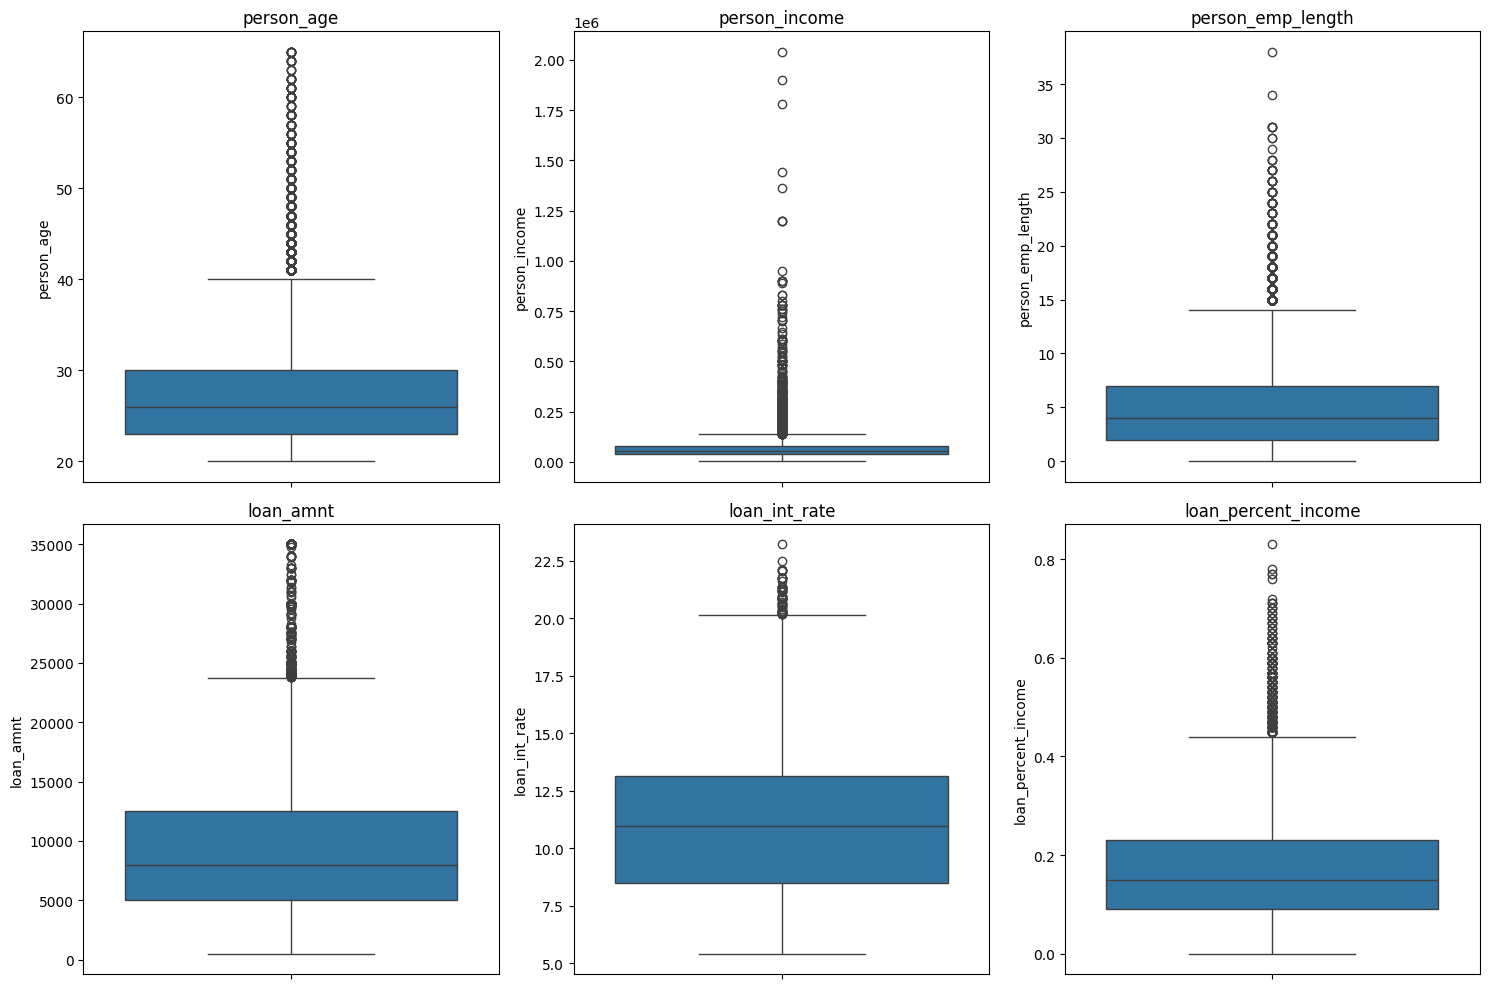

In [9]:
# Boxplot of numerical features
num_cols = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income'
]

plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.savefig("../outputs/figures/deep_eda/boxplot_numerical.png")
plt.show()

### Compare person age and person employee lenght

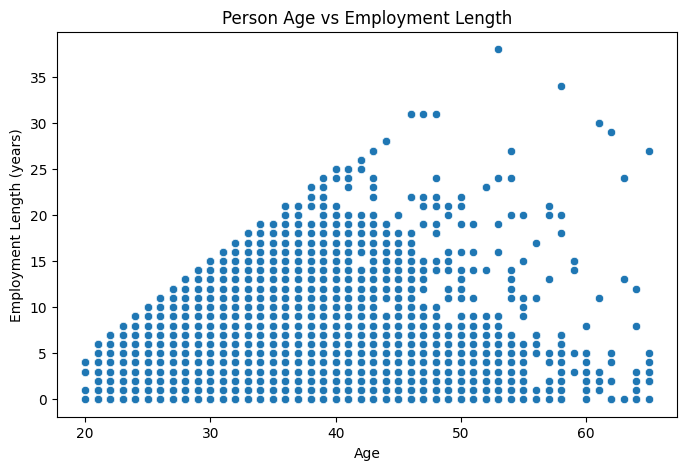

In [10]:
# Compare person age and person employee lenght
plt.figure(figsize=(8,5))
sns.scatterplot(x='person_age', y='person_emp_length', data=df)

plt.title("Person Age vs Employment Length")
plt.xlabel("Age")
plt.ylabel("Employment Length (years)")
plt.savefig("../outputs/figures/deep_eda/compare_age_emp-length.png")
plt.show()

### Plot Correlation matrix

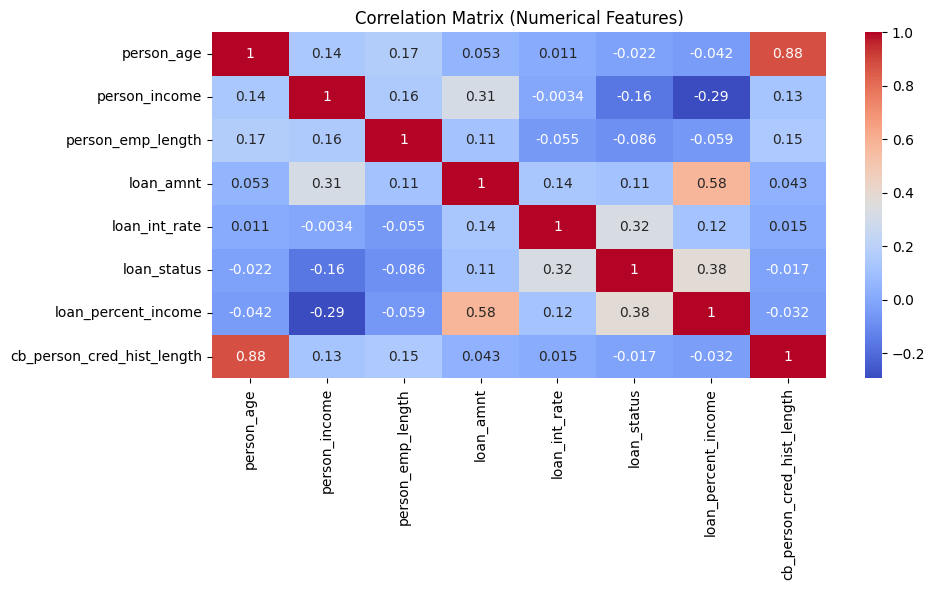

In [11]:
# Select numerical features
num_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr = num_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix (Numerical Features)")
plt.tight_layout()
plt.savefig("../outputs/figures/deep_eda/correlation_matrix.png")
plt.show()

### Categorical Feature Distribution

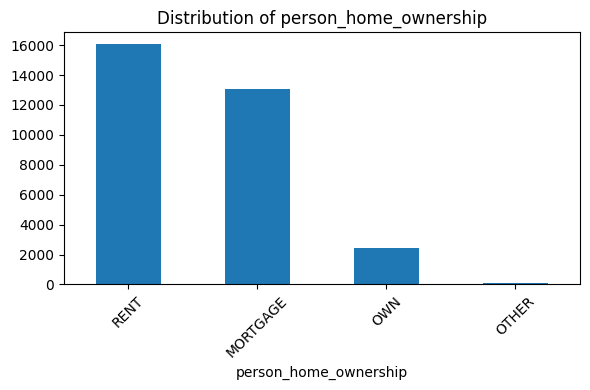

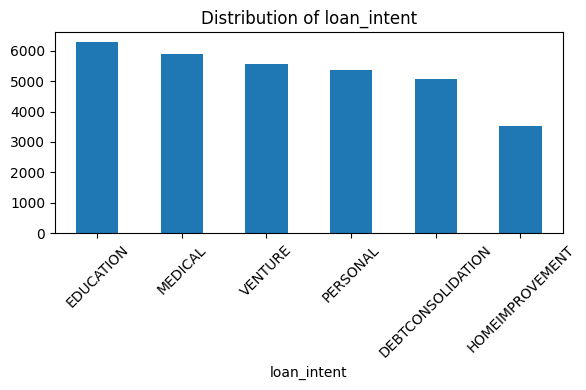

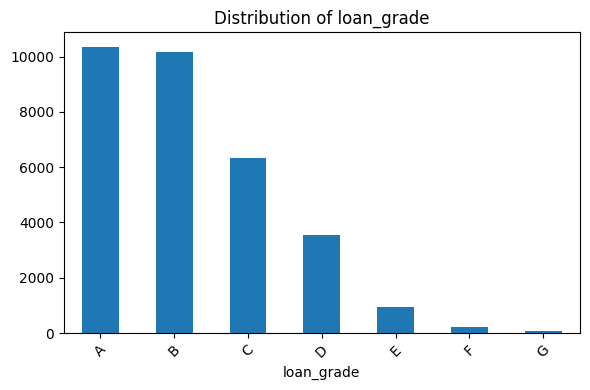

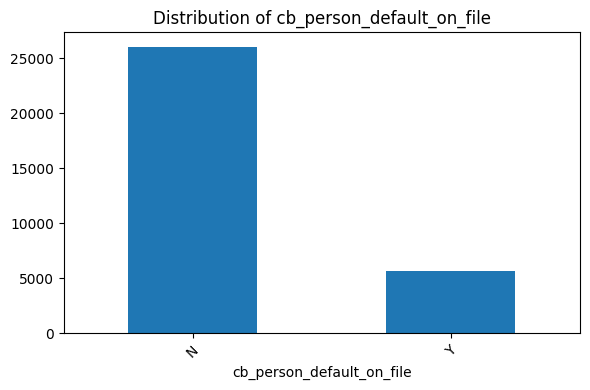

In [12]:
categorical_cols = [
    'person_home_ownership',
    'loan_intent',
    'loan_grade',
    'cb_person_default_on_file'
]

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"../outputs/figures/deep_eda/categorical_feature_distribution_{col}.png")
    plt.show()

### Relationship Between Features and Loan Status

In [13]:
df.groupby('person_home_ownership')['loan_status'].mean().sort_values(ascending=False)

person_home_ownership
RENT        0.310884
OTHER       0.308411
MORTGAGE    0.124599
OWN         0.069295
Name: loan_status, dtype: float64

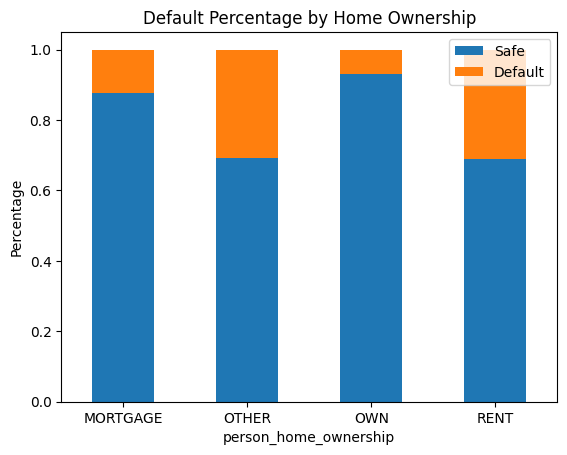

In [14]:
pd.crosstab(
    df['person_home_ownership'],
    df['loan_status'],
    normalize='index'
).plot(kind='bar', stacked=True)

plt.title('Default Percentage by Home Ownership')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(['Safe', 'Default'])
plt.savefig("../outputs/figures/deep_eda/default_percentage_by_home_ownership.png")
plt.show()

In [15]:
df.groupby('loan_intent')['loan_status'].mean().sort_values(ascending=False)

loan_intent
DEBTCONSOLIDATION    0.283485
MEDICAL              0.265862
HOMEIMPROVEMENT      0.255556
PERSONAL             0.195186
EDUCATION            0.169397
VENTURE              0.146587
Name: loan_status, dtype: float64

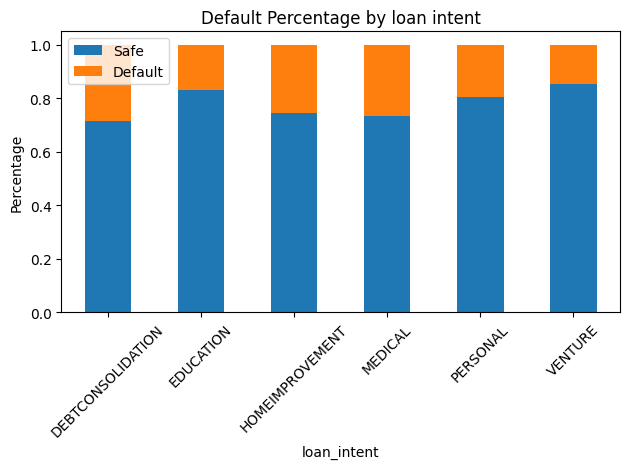

In [16]:
pd.crosstab(
    df['loan_intent'],
    df['loan_status'],
    normalize='index'
).plot(kind='bar', stacked=True)

plt.title('Default Percentage by loan intent')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.legend(['Safe', 'Default'])
plt.tight_layout()
plt.savefig("../outputs/figures/deep_eda/default_percentage_by_loan_intent.png")
plt.show()

In [17]:
df.groupby('cb_person_default_on_file')['loan_status'].mean().sort_values(ascending=False)

cb_person_default_on_file
Y    0.375378
N    0.180952
Name: loan_status, dtype: float64

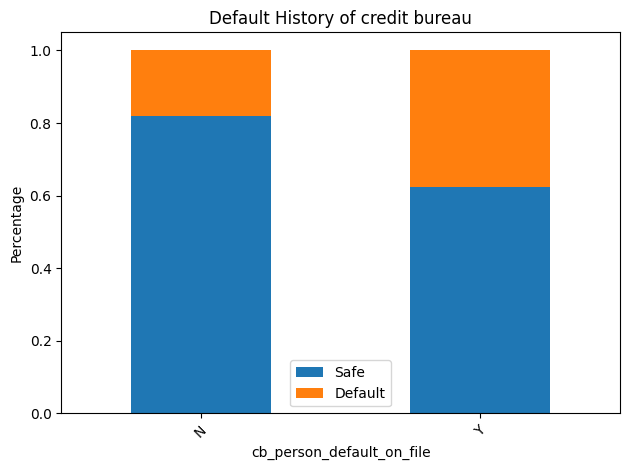

In [18]:
pd.crosstab(
    df['cb_person_default_on_file'],
    df['loan_status'],
    normalize='index'
).plot(kind='bar', stacked=True)

plt.title('Default History of credit bureau')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.legend(['Safe', 'Default'])
plt.tight_layout()
plt.savefig("../outputs/figures/deep_eda/default_history_of_credit_bureau.png")
plt.show()